In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import math
import numpy as np

In [2]:
apple = yf.Ticker("AAPL").history(period="10y")
price = apple["Close"].reset_index()["Close"]

In [3]:
arr = []
price_len = 75
step = 1

for i in range(0, len(price), step):
    if i + price_len > len(price):
        continue

    p = price[i:i+price_len]
    p = (p - min(p)) / (max(p) - min(p))

    arr.append(p.reset_index(drop=True))

In [4]:
def compute_dtw_matrix(x, y):
    N, M = len(x), len(y)
    dtw_matrix = np.full((N + 1, M + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    for i in range(1, N + 1):
        for j in range(1, M + 1):
            cost = abs(x[i - 1] - y[j - 1])
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i - 1, j],    # insertion
                dtw_matrix[i, j - 1],    # deletion
                dtw_matrix[i - 1, j - 1] # match
            )
    return dtw_matrix

def get_dtw_path_and_steps(dtw_matrix):
    i, j = dtw_matrix.shape[0] - 1, dtw_matrix.shape[1] - 1
    path = [(i - 1, j - 1)]
    
    while i > 1 or j > 1:
        neighbors = {
            "match": (i - 1, j - 1, dtw_matrix[i - 1, j - 1]),
            "insert": (i - 1, j, dtw_matrix[i - 1, j]),
            "delete": (i, j - 1, dtw_matrix[i, j - 1])
        }
        
        best_move = min(neighbors.values(), key=lambda x: x[2])
        i, j = best_move[0], best_move[1]
        path.append((i - 1, j - 1))
        
    path.reverse()
    
    num_steps = len(path)
    return path, num_steps

In [10]:
A = arr[0]
arrays = arr[75:]

results = []
mins = [10, 0]
maxs = [0, 0]

j = 75

for i, e in enumerate(arrays):
    matrix = compute_dtw_matrix(A, e)
    distance = matrix[-1, -1]
    path, steps = get_dtw_path_and_steps(matrix)

    re = distance / steps

    results.append((j, re))

    j += 1

In [11]:
sorted_array = sorted(results, key=lambda x: x[1])

In [12]:
window_size = 50
k_matches = 10
final_distinct_matches = []
forbidden_indices = set()

for index, score in sorted_array:
    # Check if this index is inside a blackout zone
    if index in forbidden_indices:
        continue 
        
    # If it is clean, add it to our final group
    final_distinct_matches.append((index, score))
    
    # Blackout the surrounding days (Exclusion Zone)
    # Block everything from (index - 50) to (index + 50)
    for i in range(index - window_size, index + window_size + 1):
        forbidden_indices.add(i)
        
    # Stop once we have our target number of independent matches
    if len(final_distinct_matches) == k_matches:
        break

In [13]:
final_distinct_matches

[(2257, np.float64(0.023293267868431222)),
 (797, np.float64(0.026007167580661187)),
 (964, np.float64(0.02651309012069491)),
 (1641, np.float64(0.028024226887653023)),
 (485, np.float64(0.02998153219923163)),
 (741, np.float64(0.031137400268178392)),
 (1962, np.float64(0.0321884573751474)),
 (133, np.float64(0.033092330562022675)),
 (1698, np.float64(0.0333729725446516)),
 (848, np.float64(0.033480532065332164))]

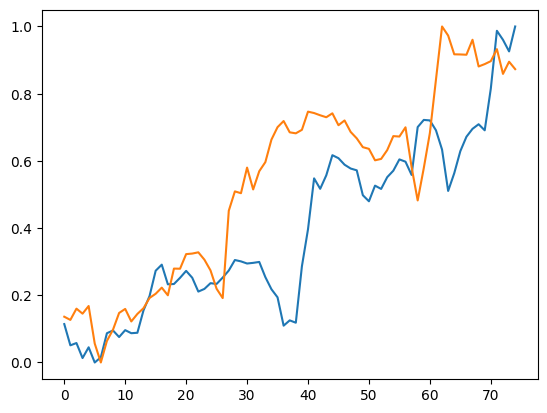

In [14]:
# plt.plot(arr[final_distinct_matches[0][0]])
# plt.plot(arr[final_distinct_matches[1][0]])
# plt.plot(arr[final_distinct_matches[2][0]])
# plt.plot(arr[final_distinct_matches[9][0]])
plt.plot(arr[final_distinct_matches[0][0]])
plt.plot(arr[0])